In [ ]:
import re
from typing import List, Dict, Any

import json

In [ ]:
import re
from typing import List, Dict, Any

def chunk_legal_document(doc: Dict[str, Any], max_chunk_size: int = 2000) -> List[Dict[str, Any]]:
    text = doc.get("nội dung", "")
    if not text:
        return []

    # --- Tìm các điều (chỉ bắt khi dòng bắt đầu bằng "Điều" + số) ---
    article_pattern = re.compile(r'^Điều\s+(\d+|[IVXLCDM]+)\s*[\.\:]?\s*(.*)$', re.MULTILINE | re.IGNORECASE)
    article_matches = list(article_pattern.finditer(text))
    if not article_matches:
        return _chunk_by_paragraphs(doc, text, max_chunk_size)

    chunks = []
    for i, match in enumerate(article_matches):
        start = match.start()
        end = article_matches[i+1].start() if i+1 < len(article_matches) else len(text)
        article_text = text[start:end].strip()
        article_number = match.group(1)
        article_title = match.group(2).strip() or None

        # Bỏ qua đoạn quá ngắn (có thể bắt nhầm)
        if len(article_text) < 50:
            continue

        # --- Tìm các khoản (dạng "1. Nội dung..." hoặc "1: Nội dung...") ---
        clause_pattern = re.compile(r'^(\d+|[IVXLCDM]+)\s*[\.\:]\s*(.*)$', re.MULTILINE)
        clause_matches = list(clause_pattern.finditer(article_text))

        if not clause_matches:
            # Không có khoản -> lưu toàn bộ điều
            chunk = doc.copy()
            chunk["chunk_content"] = article_text
            chunk["level"] = "article"
            chunk["article_number"] = article_number
            chunk["article_title"] = article_title
            chunk["clause_number"] = None
            chunk["point"] = None
            chunks.append(chunk)
        else:
            for j, cl_match in enumerate(clause_matches):
                cl_start = cl_match.start()
                cl_end = clause_matches[j+1].start() if j+1 < len(clause_matches) else len(article_text)
                clause_text = article_text[cl_start:cl_end].strip()
                clause_number = cl_match.group(1)
                clause_title = cl_match.group(2).strip() or None

                if len(clause_text) <= max_chunk_size:
                    chunk = doc.copy()
                    chunk["chunk_content"] = clause_text
                    chunk["level"] = "clause"
                    chunk["article_number"] = article_number
                    chunk["article_title"] = article_title
                    chunk["clause_number"] = clause_number
                    chunk["clause_title"] = clause_title
                    chunk["point"] = None
                    chunks.append(chunk)
                else:
                    # Tách khoản dài thành các câu (có thể mở rộng xử lý điểm a,b,c)
                    sub_chunks = _split_by_sentences(
                        doc, clause_text, article_number, clause_number,
                        article_title, max_chunk_size
                    )
                    chunks.extend(sub_chunks)
    return chunks

def _split_by_sentences(doc, text, article_number, clause_number, article_title, max_chunk_size):
    sentences = re.split(r'(?<=\.)\s+(?=[A-ZÀ-ÁÂÃÈ-ÉÊÌ-ÍÒ-ÓÔÕÙ-ÚÝĐ])', text)
    chunks = []
    current = ""
    for sent in sentences:
        if len(current) + len(sent) + 2 <= max_chunk_size:
            current += sent + " "
        else:
            if current:
                chunk = doc.copy()
                chunk["chunk_content"] = current.strip()
                chunk["level"] = "sentence"
                chunk["article_number"] = article_number
                chunk["article_title"] = article_title
                chunk["clause_number"] = clause_number
                chunk["point"] = None
                chunks.append(chunk)
            current = sent + " "
    if current:
        chunk = doc.copy()
        chunk["chunk_content"] = current.strip()
        chunk["level"] = "sentence"
        chunk["article_number"] = article_number
        chunk["article_title"] = article_title
        chunk["clause_number"] = clause_number
        chunk["point"] = None
        chunks.append(chunk)
    return chunks

def _chunk_by_paragraphs(doc, text, max_chunk_size):
    paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]
    chunks = []
    for para in paragraphs:
        if len(para) <= max_chunk_size:
            chunk = doc.copy()
            chunk["chunk_content"] = para
            chunk["level"] = "paragraph"
            chunks.append(chunk)
        else:
            sentences = re.split(r'(?<=\.)\s+(?=[A-ZÀ-ÁÂÃÈ-ÉÊÌ-ÍÒ-ÓÔÕÙ-ÚÝĐ])', para)
            current = ""
            for sent in sentences:
                if len(current) + len(sent) + 2 <= max_chunk_size:
                    current += sent + " "
                else:
                    if current:
                        chunk = doc.copy()
                        chunk["chunk_content"] = current.strip()
                        chunk["level"] = "sentence"
                        chunks.append(chunk)
                    current = sent + " "
            if current:
                chunk = doc.copy()
                chunk["chunk_content"] = current.strip()
                chunk["level"] = "sentence"
                chunks.append(chunk)
    return chunks

In [ ]:
DATA_PATH = '../../data/legal_document/metadata_law_ALL_FILTERED.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    documents = json.load(f)
print(f"Loaded {len(documents)} documents")


Loaded 12 documents


In [ ]:
from tqdm import tqdm

all_chunks = []
max_size = 2000

for doc in tqdm(documents, desc="Chunking documents"):
    chunks = chunk_legal_document(doc, max_chunk_size=max_size)
    all_chunks.extend(chunks)

print(f"Total chunks: {len(all_chunks)}")

Chunking documents: 100%|██████████| 12/12 [00:00<00:00, 667.71it/s]

Total chunks: 3315


In [ ]:
import json
if len(all_chunks) > 0:
    print('这是结果')
    print(json.dumps(all_chunks[3], ensure_ascii=False, indent=2))
else:
    print("没有")

这是结果
{
  "Tên văn bản": "Luật Sửa đổi, bổ sung một số điều của Luật Doanh nghiệp số 76/2025/QH15",
  "Số hiệu": "76/2025/QH15",
  "Ngành": "Tài chính",
  "Lĩnh vực": "Chưa phân loại",
  "Cơ quan ban hành": "Quốc hội",
  "Chức danh": "Chủ tịch",
  "Người ký": "Trần Thanh Mẫn",
  "Loại văn bản": "Luật",
  "Ngày ban hành": "17/06/2025",
  "Ngày có hiệu lực": "01/07/2025",
  "Ngày hết hiệu lực": "--",
  "Tình trạng hiệu lực": "Còn hiệu lực",
  "url": "https://vbpl.vn/van-ban/chi-tiet/luat-sua-doi-bo-sung-mot-so-dieu-cua-luat-doanh-nghiep-so-76-2025-qh15--179095",
  "nội dung": "QUỐC HỘI\nLuật số: 76/2025/QH15\nCỘNG HÒA XÃ HỘI CHỦ NGHĨA VIỆT NAM\nĐộc lập - Tự do - Hạnh phúc\n-----------------------------\nLUẬT\nSỬA ĐỔI, BỔ SUNG MỘT SỐ ĐIỀU CỦA LUẬT DOANH NGHIỆP\nCăn cứ Hiến pháp nước Cộng hòa xã hội chủ nghĩa Việt Nam đã được sửa đổi, bổ sung một số điều theo Nghị quyết số 203/2025/QH15;\nQuốc hội ban hành Luật sửa đổi, bổ sung một số điều của Luật Doanh nghiệp số 59/2020/QH14 đã được sửa đ

In [ ]:
output_chunks_path = "../../data/legal_document/all_chunks.json"
with open(output_chunks_path, "w", encoding="utf-8") as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)

print(f"Saved {len(all_chunks)} chunks to {output_chunks_path}")

Tổng số điều: 2133

--- KÝ TỰ ---
Trung bình: 546
Trung vị: 349
Min: 7
Max: 6379
Percentile 90: 1272
Percentile 95: 1653
Percentile 99: 2762

--- SỐ TỪ ---
Trung bình: 121
Trung vị: 78
Min: 2
Max: 1442
Percentile 90: 283
Percentile 95: 362
Percentile 99: 616


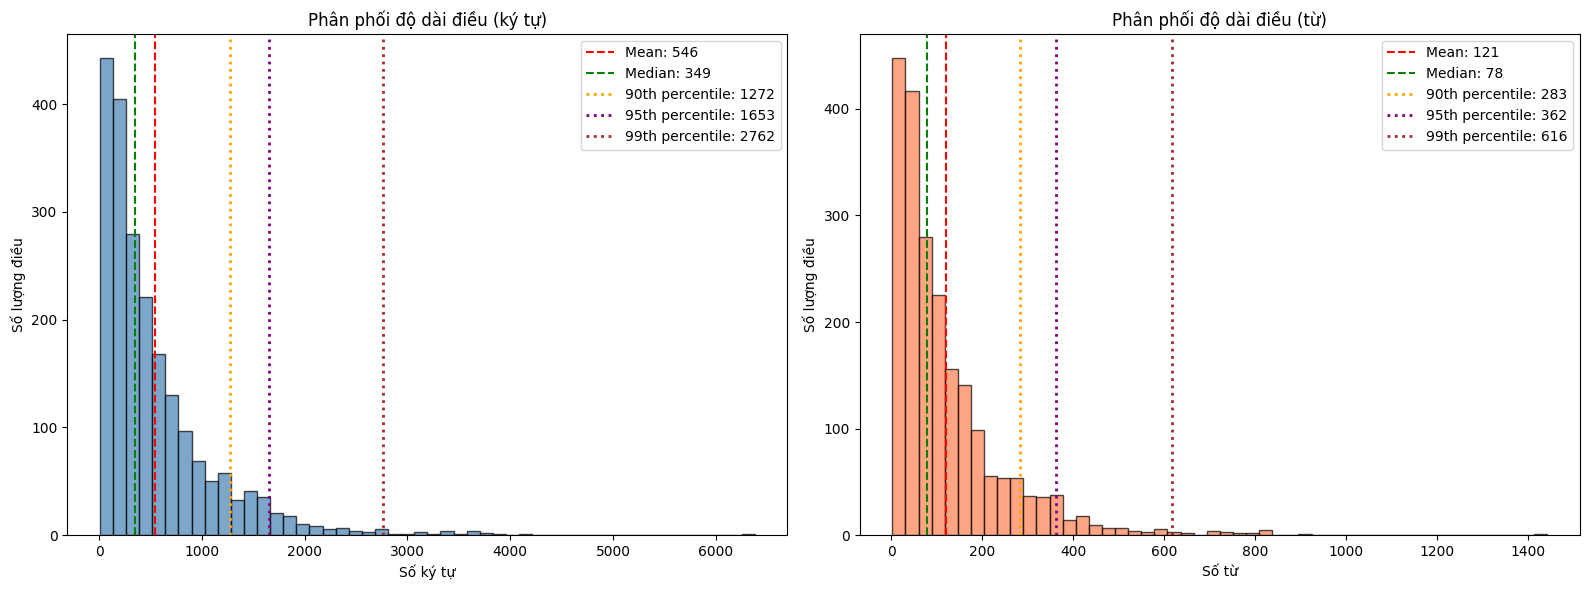

In [ ]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np

DATA_PATH = '../../data/legal_document/metadata_law_ALL_FILTERED.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    documents = json.load(f)

article_pattern = re.compile(
    r'Điều\s+(\d+|[IVXLCDM]+)\s*[\.\:]?\s*(?P<title>[^\n]*?)\s*\n',
    re.IGNORECASE
)

char_lengths = []
word_counts = []

for doc in documents:
    text = doc.get("nội dung", "")
    if not text:
        continue
    matches = list(article_pattern.finditer(text))
    if not matches:
        continue
    for i, m in enumerate(matches):
        start = m.start()
        end = matches[i+1].start() if i+1 < len(matches) else len(text)
        article_text = text[start:end].strip()
        char_lengths.append(len(article_text))
        word_counts.append(len(article_text.split()))

# Thống kê
print(f"Tổng số điều: {len(char_lengths)}")
print("\n--- KÝ TỰ ---")
print(f"Trung bình: {np.mean(char_lengths):.0f}")
print(f"Trung vị: {np.median(char_lengths):.0f}")
print(f"Min: {np.min(char_lengths)}")
print(f"Max: {np.max(char_lengths)}")
percentiles_char = [90, 95, 99]
for p in percentiles_char:
    print(f"Percentile {p}: {np.percentile(char_lengths, p):.0f}")

print("\n--- SỐ TỪ ---")
print(f"Trung bình: {np.mean(word_counts):.0f}")
print(f"Trung vị: {np.median(word_counts):.0f}")
print(f"Min: {np.min(word_counts)}")
print(f"Max: {np.max(word_counts)}")
for p in percentiles_char:
    print(f"Percentile {p}: {np.percentile(word_counts, p):.0f}")

# Vẽ biểu đồ với các đường percentile
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ký tự
axes[0].hist(char_lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(char_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(char_lengths):.0f}')
axes[0].axvline(np.median(char_lengths), color='green', linestyle='--', label=f'Median: {np.median(char_lengths):.0f}')
colors = ['orange', 'purple', 'brown']
for p, col in zip(percentiles_char, colors):
    val = np.percentile(char_lengths, p)
    axes[0].axvline(val, color=col, linestyle=':', linewidth=2, label=f'{p}th percentile: {val:.0f}')
axes[0].set_xlabel('Số ký tự')
axes[0].set_ylabel('Số lượng điều')
axes[0].set_title('Phân phối độ dài điều (ký tự)')
axes[0].legend()

# Số từ
axes[1].hist(word_counts, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(np.mean(word_counts), color='red', linestyle='--', label=f'Mean: {np.mean(word_counts):.0f}')
axes[1].axvline(np.median(word_counts), color='green', linestyle='--', label=f'Median: {np.median(word_counts):.0f}')
for p, col in zip(percentiles_char, colors):
    val = np.percentile(word_counts, p)
    axes[1].axvline(val, color=col, linestyle=':', linewidth=2, label=f'{p}th percentile: {val:.0f}')
axes[1].set_xlabel('Số từ')
axes[1].set_ylabel('Số lượng điều')
axes[1].set_title('Phân phối độ dài điều (từ)')
axes[1].legend()

plt.tight_layout()
plt.show()